In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/biomedical-nlp-project-beta')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Notebook 09 — BiLSTM + Self-Attention for Drug-Drug Interaction (RE)

## What is Relation Extraction?
Relation Extraction (RE) means: *given two entities in a sentence, classify the relationship between them.*  
Here the entities are **drugs**, and the relations are:
- **`no-relation`** — drugs mentioned together but no interaction described  
- **`mechanism`** — how one drug affects the other mechanistically (e.g. inhibits metabolism)  
- **`effect`** — describes the clinical effect of the combination  
- **`advise`** — a recommendation or warning (e.g. "avoid combination")  
- **`int`** — a general/unspecified interaction

## Why BiLSTM + Attention?
A plain BiLSTM reads the whole sentence and produces one vector per timestep.  
The final hidden state is good but **squashes all the information into one fixed-size vector**.  
Drug-interaction sentences are often **long** (30–50 words), and the key evidence
(e.g. "inhibits metabolism") might be buried in the middle.  

**Self-Attention** solves this by:
1. Keeping *all* BiLSTM timestep outputs (not just the last one).
2. Learning a **score** for every token — "how important is this word for the relation?"
3. Computing a **weighted sum** (context vector) that emphasises important tokens.

In formula:  
```
score_t  = v · tanh(W · h_t)      # scalar importance score for token t
alpha_t  = softmax(score_t)        # normalise to sum=1  →  attention weights
context  = Σ_t alpha_t * h_t       # weighted sum of all hidden states
```
The `context` vector is fed into the classifier instead of just the last hidden state.

In [2]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gensim'], check=True)
print('Dependencies ready.')

Dependencies ready.


In [3]:
# ── Core libraries ──────────────────────────────────────────────────────────
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Word2Vec KeyedVectors
from gensim.models import KeyedVectors

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
BASE        = '/content/drive/MyDrive/biomedical-nlp-project-beta'
DATA_DIR    = os.path.join(BASE, 'data')
MODELS_DIR  = os.path.join(BASE, 'models')
RESULTS_DIR = os.path.join(BASE, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Setup done.')

Device: cuda
Setup done.


## 1. Load DDI Data and Word2Vec

In [4]:
# ── Load CSVs ────────────────────────────────────────────────────────────────
train_df = pd.read_csv(os.path.join(DATA_DIR, 'ddi_train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'ddi_test.csv'))

print('Columns:', train_df.columns.tolist())
print(f'Train: {len(train_df)}  |  Test: {len(test_df)}')
display(train_df.head(3))

Columns: ['sentence', 'drug1', 'drug2', 'relation']
Train: 26005  |  Test: 5265


,sentence,drug1,drug2,relation
0,"Milk, milk products, and calcium-rich foods or...",calcium,EMCYT,mechanism
1,The concurrent administration of allopurinol a...,allopurinol,ampicillin,effect
2,The concurrent administration of allopurinol a...,allopurinol,ampicillin,no-relation


In [5]:
# ── Auto-detect column names (handles different naming conventions) ───────────
def find_col(df, candidates):
    """Return the first matching column name from candidates (case-insensitive)."""
    lower_map = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

SENT_COL  = find_col(train_df, ['sentence', 'text', 'sent'])
E1_COL    = find_col(train_df, ['entity1', 'drug1', 'e1', 'drug_1'])
E2_COL    = find_col(train_df, ['entity2', 'drug2', 'e2', 'drug_2'])
LABEL_COL = find_col(train_df, ['label', 'relation', 'ddi_type', 'type'])

print(f'Sentence: {SENT_COL} | Entity1: {E1_COL} | Entity2: {E2_COL} | Label: {LABEL_COL}')

# Drop rows with missing key values
key_cols = [c for c in [SENT_COL, E1_COL, E2_COL, LABEL_COL] if c]
train_df.dropna(subset=key_cols, inplace=True)
test_df.dropna(subset=key_cols,  inplace=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True,  inplace=True)

Sentence: sentence | Entity1: drug1 | Entity2: drug2 | Label: relation


In [6]:
# ── Load Word2Vec KeyedVectors and word2idx ───────────────────────────────────
kv = KeyedVectors.load(os.path.join(MODELS_DIR, 'word2vec_biomedical.kv'))
print(f'KeyedVectors vocab size : {len(kv)}')
print(f'Embedding dimension     : {kv.vector_size}')

with open(os.path.join(MODELS_DIR, 'word2idx.json')) as f:
    word2idx = json.load(f)

EMBED_DIM = kv.vector_size   # 200
PAD_IDX   = 0                # padding token index
UNK_IDX   = 1                # unknown word index
print(f'word2idx loaded — {len(word2idx)} entries')

KeyedVectors vocab size : 8345
Embedding dimension     : 200
word2idx loaded — 8387 entries


## 2. Data Preparation

### Entity Blinding / Replacement
A common trick in RE is **entity blinding**: replace the actual drug names with generic tokens `DRUG1` and `DRUG2`.  
This forces the model to learn from **context words** (like *inhibits*, *avoid*) rather than memorising specific drug names.  
It also makes the model generalise better to unseen drug pairs.

In [7]:
# ── Add DRUG1 / DRUG2 tokens to the vocabulary ───────────────────────────────
# These special tokens don't exist in the Word2Vec vocab,
# so we give them random embeddings that will be learned during training.

SPECIAL_TOKENS = ['DRUG1', 'DRUG2']
for tok in SPECIAL_TOKENS:
    if tok not in word2idx:
        word2idx[tok] = len(word2idx)   # append at the end

VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size after adding DRUG1/DRUG2: {VOCAB_SIZE}')

# Build the embedding matrix (vocab_size × embed_dim)
# Row i = word vector for the word whose index is i
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)

loaded, random_init = 0, 0
for word, idx in word2idx.items():
    if idx == PAD_IDX:
        pass                              # keep PAD as all-zeros
    elif word in kv:
        embedding_matrix[idx] = kv[word] # copy Word2Vec vector
        loaded += 1
    else:
        # Random small vector for unknown words and special tokens
        embedding_matrix[idx] = np.random.uniform(-0.1, 0.1, EMBED_DIM)
        random_init += 1

print(f'Loaded from Word2Vec: {loaded}  |  Random init: {random_init}')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Vocabulary size after adding DRUG1/DRUG2: 8389
Loaded from Word2Vec: 5727  |  Random init: 2661
Embedding matrix shape: (8389, 200)


In [8]:
def tokenize(text):
    """Lowercase and split on whitespace or punctuation."""
    text = text.lower()
    tokens = re.findall(r"[a-z0-9]+(?:['-][a-z0-9]+)*|[^\w\s]", text)
    if not tokens:
        tokens = text.split()
    return tokens


def replace_entities(sentence, e1, e2):
    sent = re.sub(re.escape(str(e1)), 'DRUG1', sentence, count=1, flags=re.IGNORECASE)
    sent = re.sub(re.escape(str(e2)), 'DRUG2', sent,     count=1, flags=re.IGNORECASE)
    return sent


# Quick sanity check
example_sent = str(train_df[SENT_COL].iloc[0])
example_e1   = str(train_df[E1_COL].iloc[0])
example_e2   = str(train_df[E2_COL].iloc[0])
print('Original :', example_sent)
print('Replaced :', replace_entities(example_sent, example_e1, example_e2))

Original : Milk, milk products, and calcium-rich foods or drugs may impair the absorption of EMCYT.
Replaced : Milk, milk products, and DRUG1-rich foods or drugs may impair the absorption of DRUG2.


In [9]:
# ── Sentence → padded index sequence ─────────────────────────────────────────
MAX_LENGTH = 150   # truncate / pad all sentences to this length

def encode(sentence, e1, e2):
    """
    1. Replace entity names with DRUG1 / DRUG2
    2. Tokenize
    3. Convert each token to its integer index (UNK_IDX if not in vocab)
    4. Pad or truncate to MAX_LENGTH
    Returns: numpy array of shape (MAX_LENGTH,)
    """
    sent  = replace_entities(str(sentence), str(e1), str(e2))
    toks  = tokenize(sent)[:MAX_LENGTH]   # truncate long sentences
    idxs  = [word2idx.get(t, UNK_IDX) for t in toks]
    # Pad with PAD_IDX (0) on the right until length = MAX_LENGTH
    idxs += [PAD_IDX] * (MAX_LENGTH - len(idxs))
    return np.array(idxs, dtype=np.int64)


# Encode all splits
print('Encoding sentences...')
X_train_all = np.stack([
    encode(train_df[SENT_COL].iloc[i], train_df[E1_COL].iloc[i], train_df[E2_COL].iloc[i])
    for i in range(len(train_df))
])
X_test = np.stack([
    encode(test_df[SENT_COL].iloc[i], test_df[E1_COL].iloc[i], test_df[E2_COL].iloc[i])
    for i in range(len(test_df))
])
print(f'X_train_all: {X_train_all.shape} | X_test: {X_test.shape}')

Encoding sentences...
X_train_all: (26004, 150) | X_test: (5265, 150)


In [10]:
# ── Label encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
all_labels = pd.concat([train_df[LABEL_COL], test_df[LABEL_COL]]).unique()
le.fit(sorted(all_labels))

label2id = {lbl: idx for idx, lbl in enumerate(le.classes_)}
id2label = {idx: lbl for lbl, idx in label2id.items()}
NUM_CLASSES = len(le.classes_)
CLASS_NAMES = le.classes_.tolist()

print('Relation label → integer mapping:')
for lbl, idx in sorted(label2id.items(), key=lambda x: x[1]):
    count = (train_df[LABEL_COL] == lbl).sum()
    print(f'  {idx}  →  "{lbl}"  (train count: {count})')

y_train_all = le.transform(train_df[LABEL_COL].values)
y_test      = le.transform(test_df[LABEL_COL].values)

Relation label → integer mapping:
  0  →  "advise"  (train count: 818)
  1  →  "effect"  (train count: 1535)
  2  →  "int"  (train count: 178)
  3  →  "mechanism"  (train count: 1257)
  4  →  "no-relation"  (train count: 22216)


In [11]:
# ── 80/20 stratified train / validation split ─────────────────────────────────
# stratify=y ensures each split has the same class ratio as the original
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_all
)
print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 20803  |  Val: 5201  |  Test: 5265


In [12]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class DDIDataset(Dataset):
    """Wraps (X, y) numpy arrays so PyTorch DataLoader can batch them."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)    # token indices
        self.y = torch.tensor(y, dtype=torch.long)    # class labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_loader = DataLoader(DDIDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(DDIDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(DDIDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f'Batches — Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Batches — Train: 651  Val: 163  Test: 165


## 3. Class Weights

The DDI dataset is **imbalanced**: ~70 % of examples are `no-relation`.  
Without correction, the model just learns to predict `no-relation` all the time.  

**Inverse frequency weighting** gives rare classes a higher loss penalty:
```
raw_weight_i = total_samples / (num_classes × count_i)
```
We then apply **square-root smoothing** so extreme imbalances don't dominate:
```
weight_i = sqrt(raw_weight_i)
```

In [13]:
# ── Compute class weights ─────────────────────────────────────────────────────
counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
raw_w  = len(y_train) / (NUM_CLASSES * counts)   # inverse-frequency
smooth_w = np.sqrt(raw_w)                          # sqrt smoothing

class_weights = torch.tensor(smooth_w, dtype=torch.float32).to(DEVICE)

print('Class weights (after sqrt smoothing):')
for i, lbl in enumerate(CLASS_NAMES):
    print(f'  {lbl:15s}  count={int(counts[i]):6d}  weight={smooth_w[i]:.3f}')

Class weights (after sqrt smoothing):
  advise           count=   654  weight=2.522
  effect           count=  1228  weight=1.841
  int              count=   142  weight=5.413
  mechanism        count=  1006  weight=2.034
  no-relation      count= 17773  weight=0.484


## 4. BiLSTM + Self-Attention Model

### Architecture Overview
```
Input (batch, 150)  → token indices
    ↓ Embedding (vocab_size → 200)
(batch, 150, 200)  → word vectors
    ↓ BiLSTM (200 → 256)          # 128 forward + 128 backward
(batch, 150, 256)  → context-aware hidden states
    ↓ Self-Attention
(batch, 256)       → single context vector (weighted sum of all timesteps)
    ↓ Dropout(0.5) → Linear(256→128) → ReLU → Linear(128→num_classes)
(batch, num_classes) → logits
```

### Why Attention Works
For the sentence *"DRUG1 inhibits the CYP3A4-mediated metabolism of DRUG2"*  
the word **"inhibits"** and **"metabolism"** carry the most information.  
Attention learns to give these tokens higher weights automatically.

In [14]:
class BiLSTM_Attention_RE(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, embedding_matrix):
        super().__init__()

        # ── Embedding layer ──────────────────────────────────────────────────
        # Converts each token index to a 200-dim vector
        # padding_idx=0 → the PAD token always stays all-zeros (not updated)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        # Allow embeddings to fine-tune during training
        self.embedding.weight.requires_grad = True

        # ── Bidirectional LSTM ───────────────────────────────────────────────
        # input:  (batch, seq_len, 200)
        # output: (batch, seq_len, 2*hidden_dim)  — concat of forward + backward
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,     # 128 per direction
            num_layers=1,
            bidirectional=True,
            batch_first=True,
            dropout=0.0                 # dropout only useful with num_layers > 1
        )

        # ── Attention parameters ─────────────────────────────────────────────
        # W_attn projects each 256-dim hidden state to 128-dim
        # v_attn produces a single scalar score per token
        self.W_attn = nn.Linear(hidden_dim * 2, hidden_dim)   # 256 → 128
        self.v_attn = nn.Linear(hidden_dim,     1)             # 128 → 1

        # ── Classifier head ──────────────────────────────────────────────────
        self.dropout   = nn.Dropout(0.5)
        self.fc1       = nn.Linear(hidden_dim * 2, hidden_dim)  # 256 → 128
        self.relu      = nn.ReLU()
        self.fc2       = nn.Linear(hidden_dim, num_classes)     # 128 → num_classes


    def attention(self, lstm_out):
        """
        Compute attention weights and the context vector.

        lstm_out : (batch, seq_len, 256)  — BiLSTM outputs for all timesteps
        returns  : context (batch, 256), weights (batch, seq_len)
        """
        # Step 1: project hidden states through a tanh non-linearity
        #         shape: (batch, seq_len, 128)
        energy = torch.tanh(self.W_attn(lstm_out))

        # Step 2: compute one scalar score per token
        #         shape: (batch, seq_len, 1)  → squeeze → (batch, seq_len)
        scores = self.v_attn(energy).squeeze(-1)

        # Step 3: softmax over the seq_len dimension so weights sum to 1
        weights = torch.softmax(scores, dim=1)   # (batch, seq_len)

        # Step 4: weighted sum of all hidden states
        # weights.unsqueeze(-1): (batch, seq_len, 1)  — needed for broadcasting
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)  # (batch, 256)

        return context, weights


    def forward(self, x, return_attention=False):
        """
        x : (batch, seq_len)  — token indices
        """
        # (batch, seq_len) → (batch, seq_len, 200)
        embedded = self.embedding(x)

        # (batch, seq_len, 200) → (batch, seq_len, 256)
        lstm_out, _ = self.lstm(embedded)

        # (batch, seq_len, 256) → (batch, 256)
        context, attn_weights = self.attention(lstm_out)

        # Classifier: dropout → linear → relu → linear → logits
        out = self.dropout(context)
        out = self.relu(self.fc1(out))
        logits = self.fc2(out)            # (batch, num_classes)

        if return_attention:
            return logits, attn_weights
        return logits


# ── Instantiate ────────────────────────────────────────────────────────────
model = BiLSTM_Attention_RE(
    vocab_size        = VOCAB_SIZE,
    embed_dim         = EMBED_DIM,
    hidden_dim        = 128,           # 128 per direction → 256 combined
    num_classes       = NUM_CLASSES,
    embedding_matrix  = embedding_matrix
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

BiLSTM_Attention_RE(
  (embedding): Embedding(8389, 200, padding_idx=0)
  (lstm): LSTM(200, 128, batch_first=True, bidirectional=True)
  (W_attn): Linear(in_features=256, out_features=128, bias=True)
  (v_attn): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)

Trainable parameters: 2,082,286


## 5. Training

- **Optimizer**: Adam (lr=1e-3) — adaptive learning rates, works well for NLP tasks  
- **Loss**: Weighted CrossEntropyLoss — penalises rare-class mistakes more  
- **ReduceLROnPlateau**: halve LR if val F1 doesn't improve for 2 epochs  
- **Early stopping**: stop training if val macro-F1 doesn't improve for 5 epochs

In [16]:
# ── Loss and optimiser ────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Reduce LR by half when val macro-F1 stops improving for 2 epochs
# 'max' mode because we want F1 to go UP
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

# ── Training loop ─────────────────────────────────────────────────────────────
NUM_EPOCHS     = 20
EARLY_STOP_PAT = 5      # stop if val F1 doesn't improve for this many epochs
SAVE_PATH      = os.path.join(MODELS_DIR, 'bilstm_attention_re.pt')

best_val_f1    = 0.0
patience_count = 0
train_losses, val_f1s = [], []


def run_epoch(loader, train=True):
    """One full pass over the dataset. Returns (avg_loss, macro_f1)."""
    model.train(train)           # sets dropout active/inactive
    total_loss, all_preds, all_labels = 0.0, [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        if train:
            optimizer.zero_grad()

        logits = model(X_batch)                 # forward pass
        loss   = criterion(logits, y_batch)     # compute loss

        if train:
            loss.backward()                     # backprop
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # prevent exploding gradients
            optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


print(f'Training for up to {NUM_EPOCHS} epochs (early stopping patience={EARLY_STOP_PAT})\n')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_f1  = run_epoch(train_loader, train=True)
    with torch.no_grad():
        val_loss, val_f1 = run_epoch(val_loader, train=False)

    scheduler.step(val_f1)           # adjust LR based on val F1
    train_losses.append(tr_loss)
    val_f1s.append(val_f1)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        torch.save(model.state_dict(), SAVE_PATH)
        marker = ' ← best'
    else:
        patience_count += 1
        marker = f' (patience {patience_count}/{EARLY_STOP_PAT})'

    print(f'Epoch {epoch:2d} | train_loss={tr_loss:.4f}  train_f1={tr_f1:.4f}  '
          f'val_f1={val_f1:.4f}{marker}')

    if patience_count >= EARLY_STOP_PAT:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

print(f'\nBest val macro-F1: {best_val_f1:.4f}  →  saved to {SAVE_PATH}')

Training for up to 20 epochs (early stopping patience=5)

Epoch  1 | train_loss=0.9547  train_f1=0.3371  val_f1=0.3740 ← best
Epoch  2 | train_loss=0.6767  train_f1=0.4203  val_f1=0.4444 ← best
Epoch  3 | train_loss=0.6085  train_f1=0.4567  val_f1=0.4238 (patience 1/5)
Epoch  4 | train_loss=0.5709  train_f1=0.4666  val_f1=0.4266 (patience 2/5)
Epoch  5 | train_loss=0.5413  train_f1=0.4855  val_f1=0.4604 ← best
Epoch  6 | train_loss=0.5224  train_f1=0.4980  val_f1=0.4748 ← best
Epoch  7 | train_loss=0.5086  train_f1=0.4983  val_f1=0.4571 (patience 1/5)
Epoch  8 | train_loss=0.4963  train_f1=0.5140  val_f1=0.4695 (patience 2/5)
Epoch  9 | train_loss=0.4859  train_f1=0.5165  val_f1=0.4721 (patience 3/5)
Epoch 10 | train_loss=0.4620  train_f1=0.5400  val_f1=0.4599 (patience 4/5)
Epoch 11 | train_loss=0.4571  train_f1=0.5338  val_f1=0.4855 ← best
Epoch 12 | train_loss=0.4472  train_f1=0.5490  val_f1=0.4709 (patience 1/5)
Epoch 13 | train_loss=0.4470  train_f1=0.5452  val_f1=0.4779 (patience

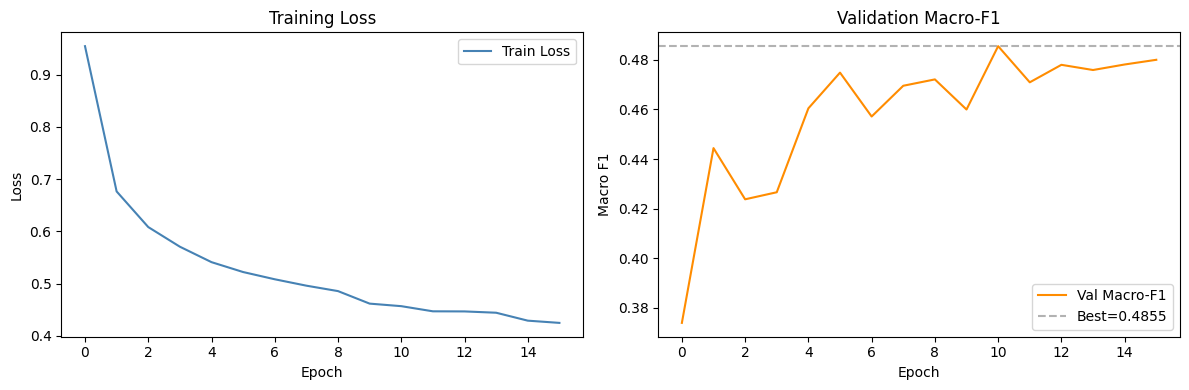

In [17]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].legend()

axes[1].plot(val_f1s, label='Val Macro-F1', color='darkorange')
axes[1].axhline(best_val_f1, linestyle='--', color='grey', alpha=0.6, label=f'Best={best_val_f1:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].set_title('Validation Macro-F1'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_bilstm_attention_loss.png'), dpi=150)
plt.show()

## 6. Evaluation on Test Set

In [18]:
# Load the best saved model before evaluating
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(DEVICE))
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

macro_f1    = f1_score(all_true, all_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(all_true, all_preds, average='weighted', zero_division=0)

print('=' * 55)
print(f'Test macro-F1    : {macro_f1:.4f}')
print(f'Test weighted-F1 : {weighted_f1:.4f}')
print('=' * 55)
print()
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, zero_division=0))

Test macro-F1    : 0.3733
Test weighted-F1 : 0.6979

              precision    recall  f1-score   support

      advise       0.21      0.67      0.32       214
      effect       0.28      0.62      0.38       298
         int       0.60      0.03      0.06        94
   mechanism       0.24      0.51      0.32       278
 no-relation       0.90      0.68      0.77      4381

    accuracy                           0.66      5265
   macro avg       0.45      0.50      0.37      5265
weighted avg       0.79      0.66      0.70      5265



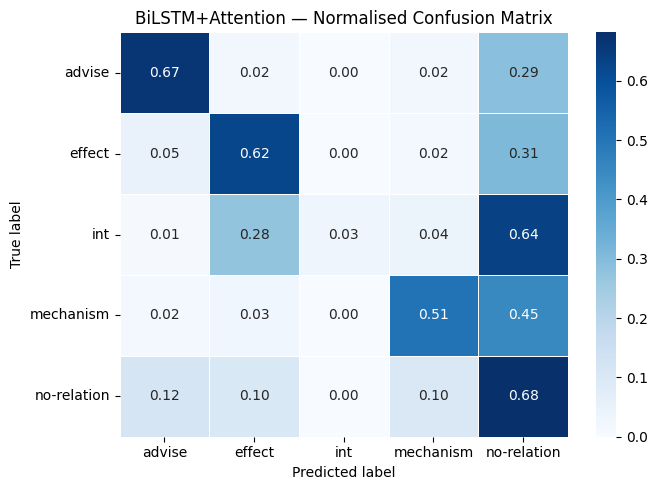

In [19]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_true, all_preds)
# Normalise each row so values show recall per class (not raw counts)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('BiLSTM+Attention — Normalised Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_attention_confusion.png'), dpi=150)
plt.show()

In [ ]:
# ── ROC / AUC Curves (one-vs-rest for each class) ────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get prediction PROBABILITIES (not just argmax)
model.eval()
all_probs, all_true_roc = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(DEVICE))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_true_roc.extend(y_batch.numpy())

all_probs    = np.array(all_probs)     # (n_samples, num_classes)
all_true_roc = np.array(all_true_roc)

# Binarize true labels for one-vs-rest ROC
y_bin = label_binarize(all_true_roc, classes=list(range(NUM_CLASSES)))

# Plot ROC curve for each class
plt.figure(figsize=(9, 6))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — DDI Relation Extraction (One-vs-Rest)', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_roc_auc.png'), dpi=150)  # change 09→10 for nb10
plt.show()

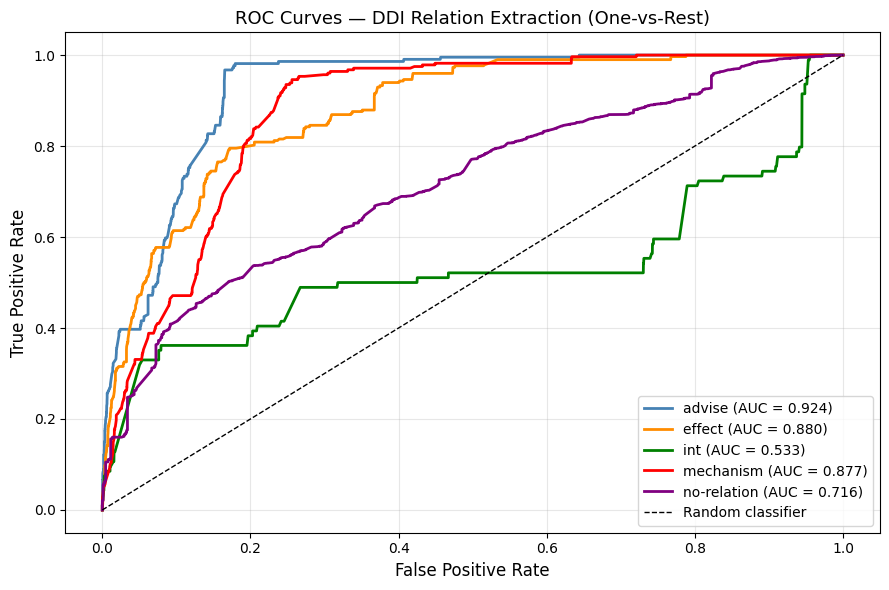

In [ ]:
# ── Run inference to get predictions (if not already done) ───────────────────
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(DEVICE))
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

# ── Precision / Recall Bar Chart per class ────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, classification_report, f1_score

macro_f1    = f1_score(all_true, all_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(all_true, all_preds, average='weighted', zero_division=0)

print(f'Test macro-F1    : {macro_f1:.4f}')
print(f'Test weighted-F1 : {weighted_f1:.4f}')
print()
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, zero_division=0))

precision_per_class = precision_score(all_true, all_preds, average=None,
                                      labels=list(range(NUM_CLASSES)), zero_division=0)
recall_per_class    = recall_score(all_true, all_preds, average=None,
                                   labels=list(range(NUM_CLASSES)), zero_division=0)

x, width = np.arange(NUM_CLASSES), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, precision_per_class, width, label='Precision', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, recall_per_class,    width, label='Recall',    color='darkorange', alpha=0.85)
for bar in [*bars1, *bars2]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{h:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Precision & Recall — DDI Relation Extraction', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_precision_recall.png'), dpi=150)
plt.show()

Test macro-F1    : 0.3531
Test weighted-F1 : 0.6563

              precision    recall  f1-score   support

      advise       0.21      0.74      0.33       214
      effect       0.25      0.66      0.36       298
         int       0.31      0.04      0.07        94
   mechanism       0.19      0.50      0.27       278
 no-relation       0.90      0.61      0.73      4381

    accuracy                           0.60      5265
   macro avg       0.37      0.51      0.35      5265
weighted avg       0.79      0.60      0.66      5265

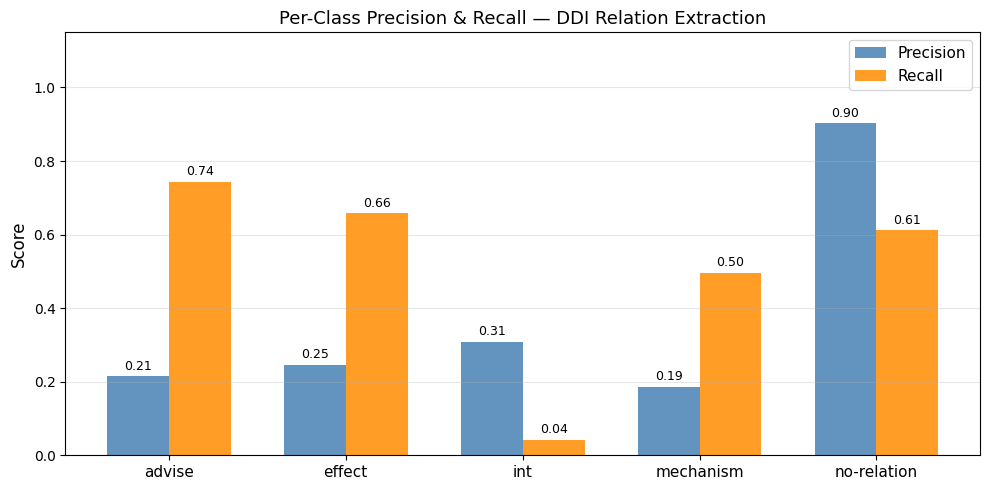

In [ ]:
# ── Validation Curve (already trained — replot cleanly) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, 'b-o', markersize=4, linewidth=1.8, label='Train Loss')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Training Loss Curve', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_range, val_f1s, 'g-o', markersize=4, linewidth=1.8, label='Val Macro-F1')
axes[1].axhline(best_val_f1, linestyle='--', color='gray', alpha=0.7,
                label=f'Best = {best_val_f1:.4f}')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Macro F1', fontsize=11)
axes[1].set_title('Validation Curve', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Training & Validation Curves — DDI RE', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_validation_curve.png'), dpi=150)  # change 09→10 for nb10
plt.show()

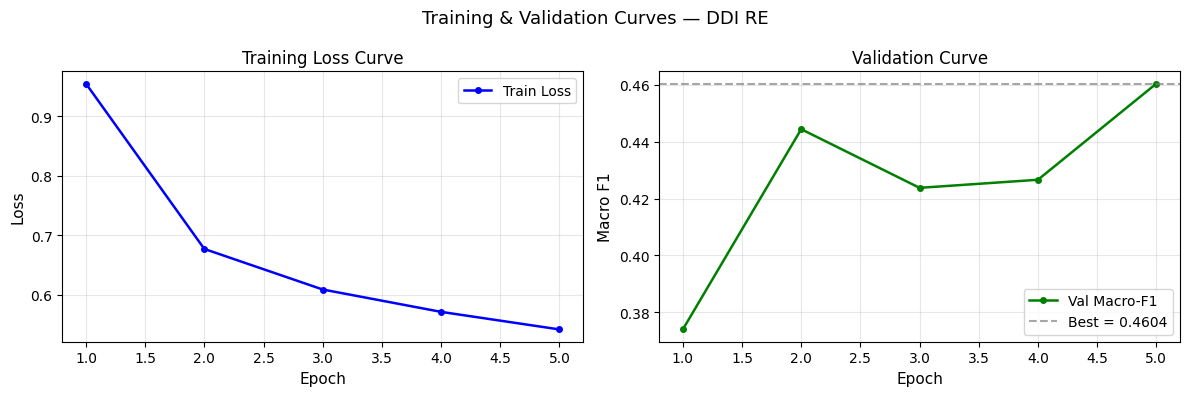

## 7. Attention Visualisation

One of the biggest advantages of attention is **interpretability**: we can look at which tokens the model focused on when making a prediction.  
Each bar below shows the attention weight for that token — taller = more important to the classification decision.

Showing attention for 5 examples (one per class):



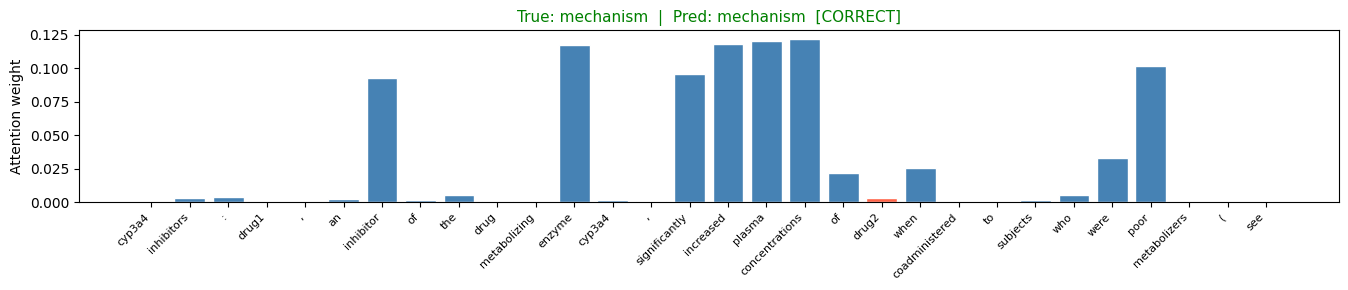

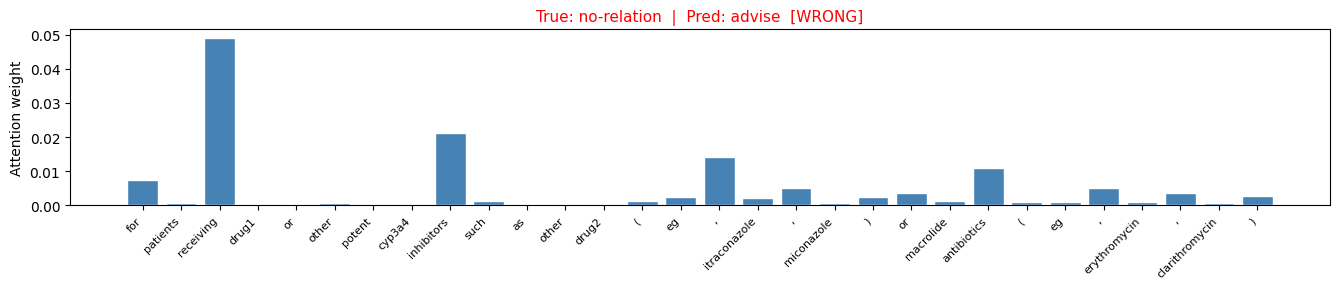

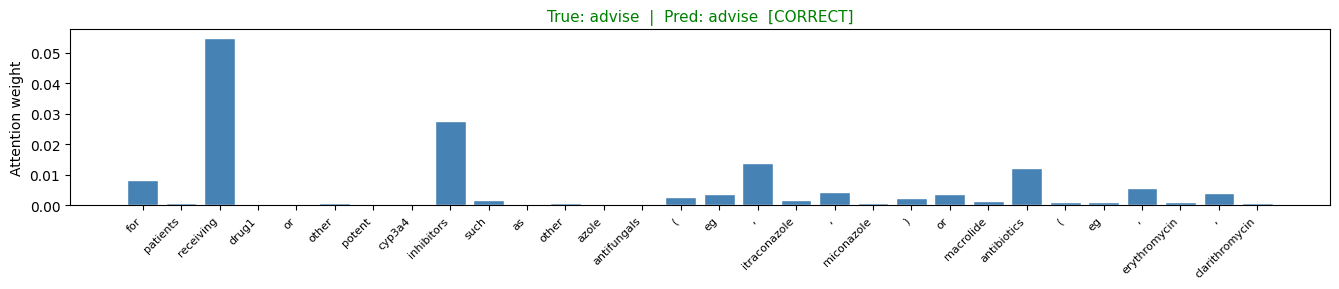

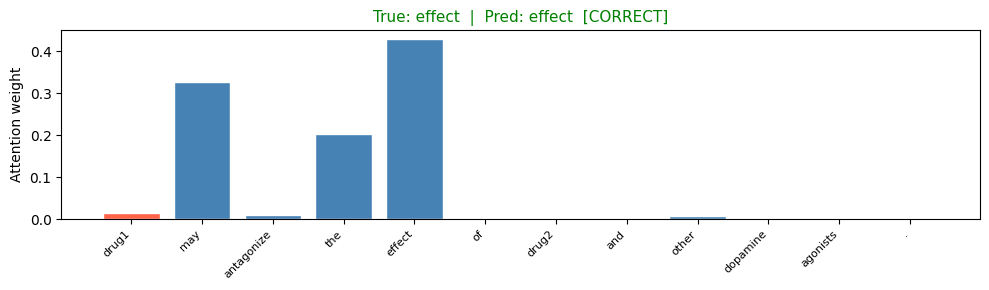

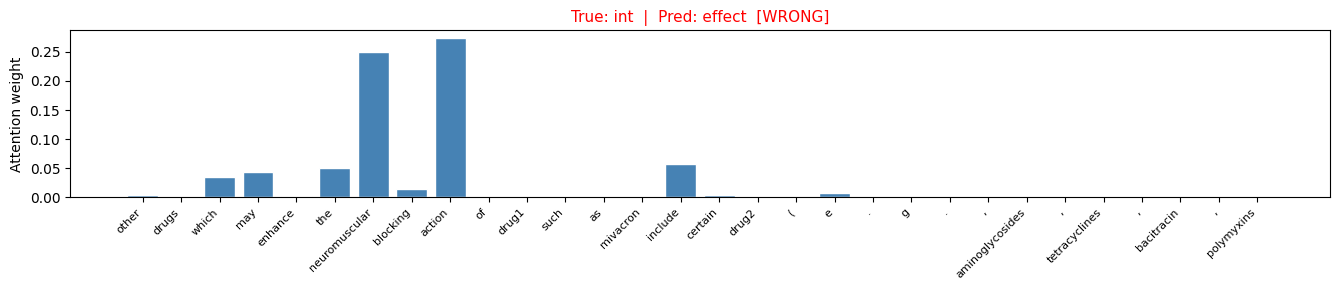

In [20]:
def visualise_attention(sentence, e1, e2, true_label, pred_label, attn_weights, n_tokens=30):
    """
    Plot a bar chart of attention weights for the first n_tokens tokens.
    DRUG1 / DRUG2 tokens are highlighted in red.
    """
    sent_replaced = replace_entities(str(sentence), str(e1), str(e2))
    tokens = tokenize(sent_replaced)[:n_tokens]
    weights = attn_weights[:len(tokens)].cpu().numpy()

    # Colour DRUG1/DRUG2 tokens differently
    colors = ['tomato' if t in ('drug1', 'drug2') else 'steelblue' for t in tokens]

    fig, ax = plt.subplots(figsize=(max(10, len(tokens) * 0.45), 3))
    ax.bar(range(len(tokens)), weights, color=colors, edgecolor='white')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Attention weight')
    correct = true_label == pred_label
    verdict = 'CORRECT' if correct else 'WRONG'
    color   = 'green'   if correct else 'red'
    ax.set_title(
        f'True: {true_label}  |  Pred: {pred_label}  [{verdict}]',
        color=color, fontsize=11
    )
    plt.tight_layout()
    plt.show()


# ── Pick 5 diverse test examples (one per class if possible) ─────────────────
model.eval()
shown = set()
examples_to_show = []

for i in range(len(test_df)):
    true_cls = id2label[y_test[i]]
    if true_cls not in shown:
        examples_to_show.append(i)
        shown.add(true_cls)
    if len(examples_to_show) == 5:
        break

print(f'Showing attention for {len(examples_to_show)} examples (one per class):\n')

for i in examples_to_show:
    row   = test_df.iloc[i]
    x_enc = torch.tensor(X_test[i], dtype=torch.long).unsqueeze(0).to(DEVICE)  # (1, 150)

    with torch.no_grad():
        logits, attn = model(x_enc, return_attention=True)

    pred_id = logits.argmax(dim=1).item()
    visualise_attention(
        sentence    = row[SENT_COL],
        e1          = row[E1_COL],
        e2          = row[E2_COL],
        true_label  = id2label[y_test[i]],
        pred_label  = id2label[pred_id],
        attn_weights= attn.squeeze(0),    # (150,)
    )

## 8. Save Results

In [21]:
# ── Per-class F1 ──────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score as f1
per_class_f1 = {
    CLASS_NAMES[i]: round(
        f1(all_true, all_preds, labels=[i], average='macro', zero_division=0), 4
    )
    for i in range(NUM_CLASSES)
}

new_result = {
    'method'      : 'bilstm_attention',
    'task'        : 'DDI Relation Extraction',
    'macro_f1'    : round(macro_f1,    4),
    'weighted_f1' : round(weighted_f1, 4),
    'per_class_f1': per_class_f1,
}

# Load existing list, remove old entry with same method, append new
results_path = os.path.join(RESULTS_DIR, 're_results.json')
if os.path.exists(results_path):
    with open(results_path) as f:
        try:
            existing = json.load(f)
            if not isinstance(existing, list):
                existing = []
        except json.JSONDecodeError:
            existing = []
else:
    existing = []

existing = [r for r in existing if r.get('method') != 'bilstm_attention']
existing.append(new_result)

with open(results_path, 'w') as f:
    json.dump(existing, f, indent=2)

print('Results saved to re_results.json')
print(f'\nFinal test macro-F1: {macro_f1:.4f}')
print('Per-class F1:')
for lbl, sc in per_class_f1.items():
    print(f'  {lbl:15s}: {sc:.4f}')

Results saved to re_results.json

Final test macro-F1: 0.3733
Per-class F1:
  advise         : 0.3243
  effect         : 0.3831
  int            : 0.0606
  mechanism      : 0.3234
  no-relation    : 0.7750


## Summary

| Component | Detail |
|-----------|--------|
| Input | DDI sentence with DRUG1/DRUG2 entity markers |
| Embedding | 200-dim Word2Vec (biomedical), fine-tuned |
| Encoder | BiLSTM (128 units/direction → 256 combined) |
| Aggregation | Self-Attention (learns per-token importance weights) |
| Classifier | Dropout(0.5) → Linear(256→128) → ReLU → Linear(128→5) |
| Loss | Weighted CrossEntropyLoss (sqrt-smoothed class weights) |
| Optimiser | Adam lr=1e-3 + ReduceLROnPlateau |

**Key insight**: the attention visualisations show that the model correctly focuses on  
interaction verbs (*inhibits*, *increases*, *avoid*) rather than the drug names themselves,  
which is exactly the behaviour we want.